In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fno_definitions import*
import torch
from FFEM_building_blocks import Mesh

# Automatic generation of source functions and the Poisson solution algorithm
# For the moment I keep a small number of modes and max frequencies, 
# otherwise the dimensionality of the training dataset rises too quickly and the training becomes mofre complicated
# I use the same function in the create_training_dataset.py file

def generate_source_function(num_modes:int=3, max_freq:int=4, max_amplitude = 1.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)
    ky = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function

# Literature

1) FNO for differential equations (original paper)
https://arxiv.org/abs/2010.08895

2) General introduction, complete
https://arxiv.org/abs/2512.01421v2, see NeuralOperator 2.0.0 library

# Minor stuff and trials

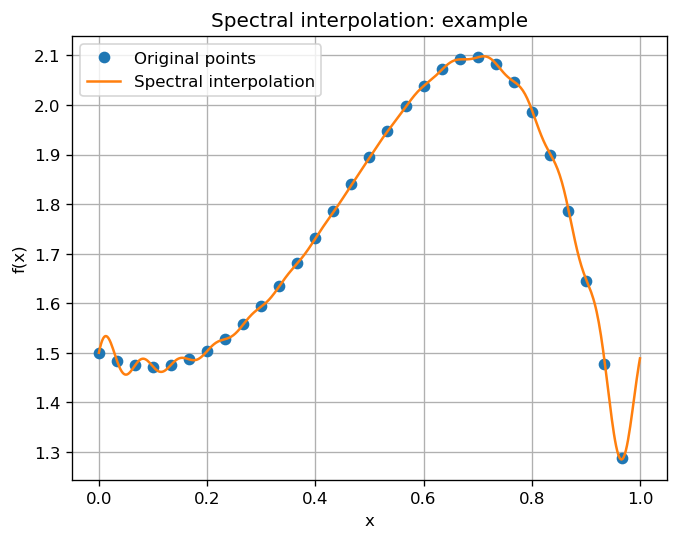

In [2]:
# test: spectral interpolation of 1d vector

def spectral_interpolation(signal: torch.tensor, M: int) -> torch.Tensor:

    """Gives the spectral interpolation of a 1d array on M points. Following 2), page 16"""
    N = len(signal) 
    fft_coeffs = torch.fft.fft(signal)
    pos_freqs = fft_coeffs[:N//2 + 1]
    neg_freqs = fft_coeffs[N//2 + 1:]

    fft_coeffs_padded = torch.cat([pos_freqs, torch.zeros(M - N), neg_freqs])

    return (torch.fft.ifft(fft_coeffs_padded).real)*M/N # the interpolated signal, scale by M/N to preserve energy


f = lambda x: torch.sin(3*x**2) + 0.5*torch.cos(torch.sqrt(x)) + 1.0 - x/3.

N = 30
xx = torch.linspace(0, 1, N+1)[:-1] # data x_n, n from 0 to N-1 

M_eval = 500

plt.figure(dpi = 120)
plt.title('Spectral interpolation: example')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(х)')
plt.plot(xx, f(xx), 'o', label = 'Original points')
plt.plot(torch.linspace(0, 1, M_eval), spectral_interpolation(f(xx), M_eval), label = 'Spectral interpolation')
plt.legend()
plt.show()

# First FNO trial (with definition from `fno_definitions.py`)

In [3]:
# a 64x64 grid with 2000 test functions nearly eats up all of my computer's RAM (16BG)
# for the moment trying on a smaller 48x48 grid with 1000 test functions

# start with something reasonably small
fno_trial = FNO_v1(n_modes = [16,16], hidden_dimension = 24, lr = 1e-3)

# REMARK: note that compared to the way I set up the deepONets, here the X and Y (input and output) arrays are kept 2d and not flattened with .ravel().
# this is because I need to distinguish the two directions for the 2d fft to be applicable

# the solutions in the dataset are computed on the [-1, 1] 2d-square, on a 64x64 grid
fno_trial.fit_from_npz('data/dataset_for_fno.npz', 30)

# mini-batching greatly help convergence towards non-uniform results

Y std across samples: 0.04481997713446617
Y std across points:  0.026096409186720848


/Users/filippo/Desktop/neural_operators/fno_definitions.py:82: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 48, 25, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_x = torch.fft.rfftn(x, dim=(-3, -2))
/Users/filippo/Desktop/neural_operators/fno_definitions.py:91: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 48, 48, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements w

Epoch [10/30], Loss: 0.0013, Loss eval: 0.0013


/Users/filippo/Desktop/neural_operators/fno_definitions.py:82: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [800, 48, 25, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_x = torch.fft.rfftn(x, dim=(-3, -2))
/Users/filippo/Desktop/neural_operators/fno_definitions.py:91: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [800, 48, 48, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements

prediction std across samples: 0.02814667858183384
prediction std across points: 0.018020031973719597
Epoch [20/30], Loss: 0.0013, Loss eval: 0.0012
prediction std across samples: 0.030985891819000244
prediction std across points: 0.019072532653808594
Epoch [30/30], Loss: 0.0013, Loss eval: 0.0012
prediction std across samples: 0.031116584315896034
prediction std across points: 0.01940663531422615


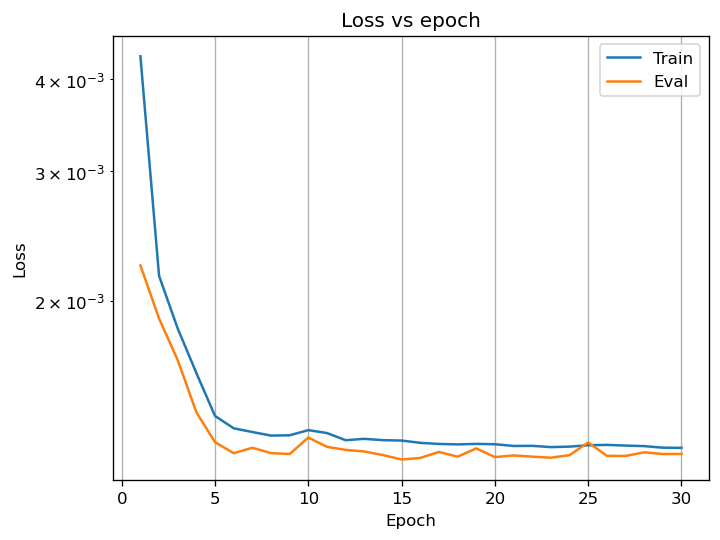

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_61464/3426932002.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


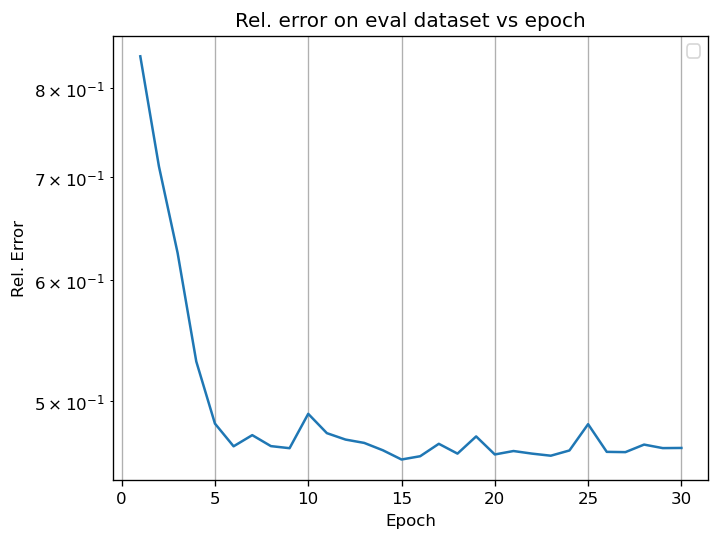

In [4]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(fno_trial.epochs, fno_trial.losses, label = "Train")
plt.semilogy(fno_trial.epochs, fno_trial.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(fno_trial.epochs, fno_trial.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

**Problem: overfitting**

Mass matrix initialization completed
Stiffness matrix initialization completed


/Users/filippo/Desktop/neural_operators/fno_definitions.py:82: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 200, 101, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_x = torch.fft.rfftn(x, dim=(-3, -2))
/Users/filippo/Desktop/neural_operators/fno_definitions.py:91: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 200, 200, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements

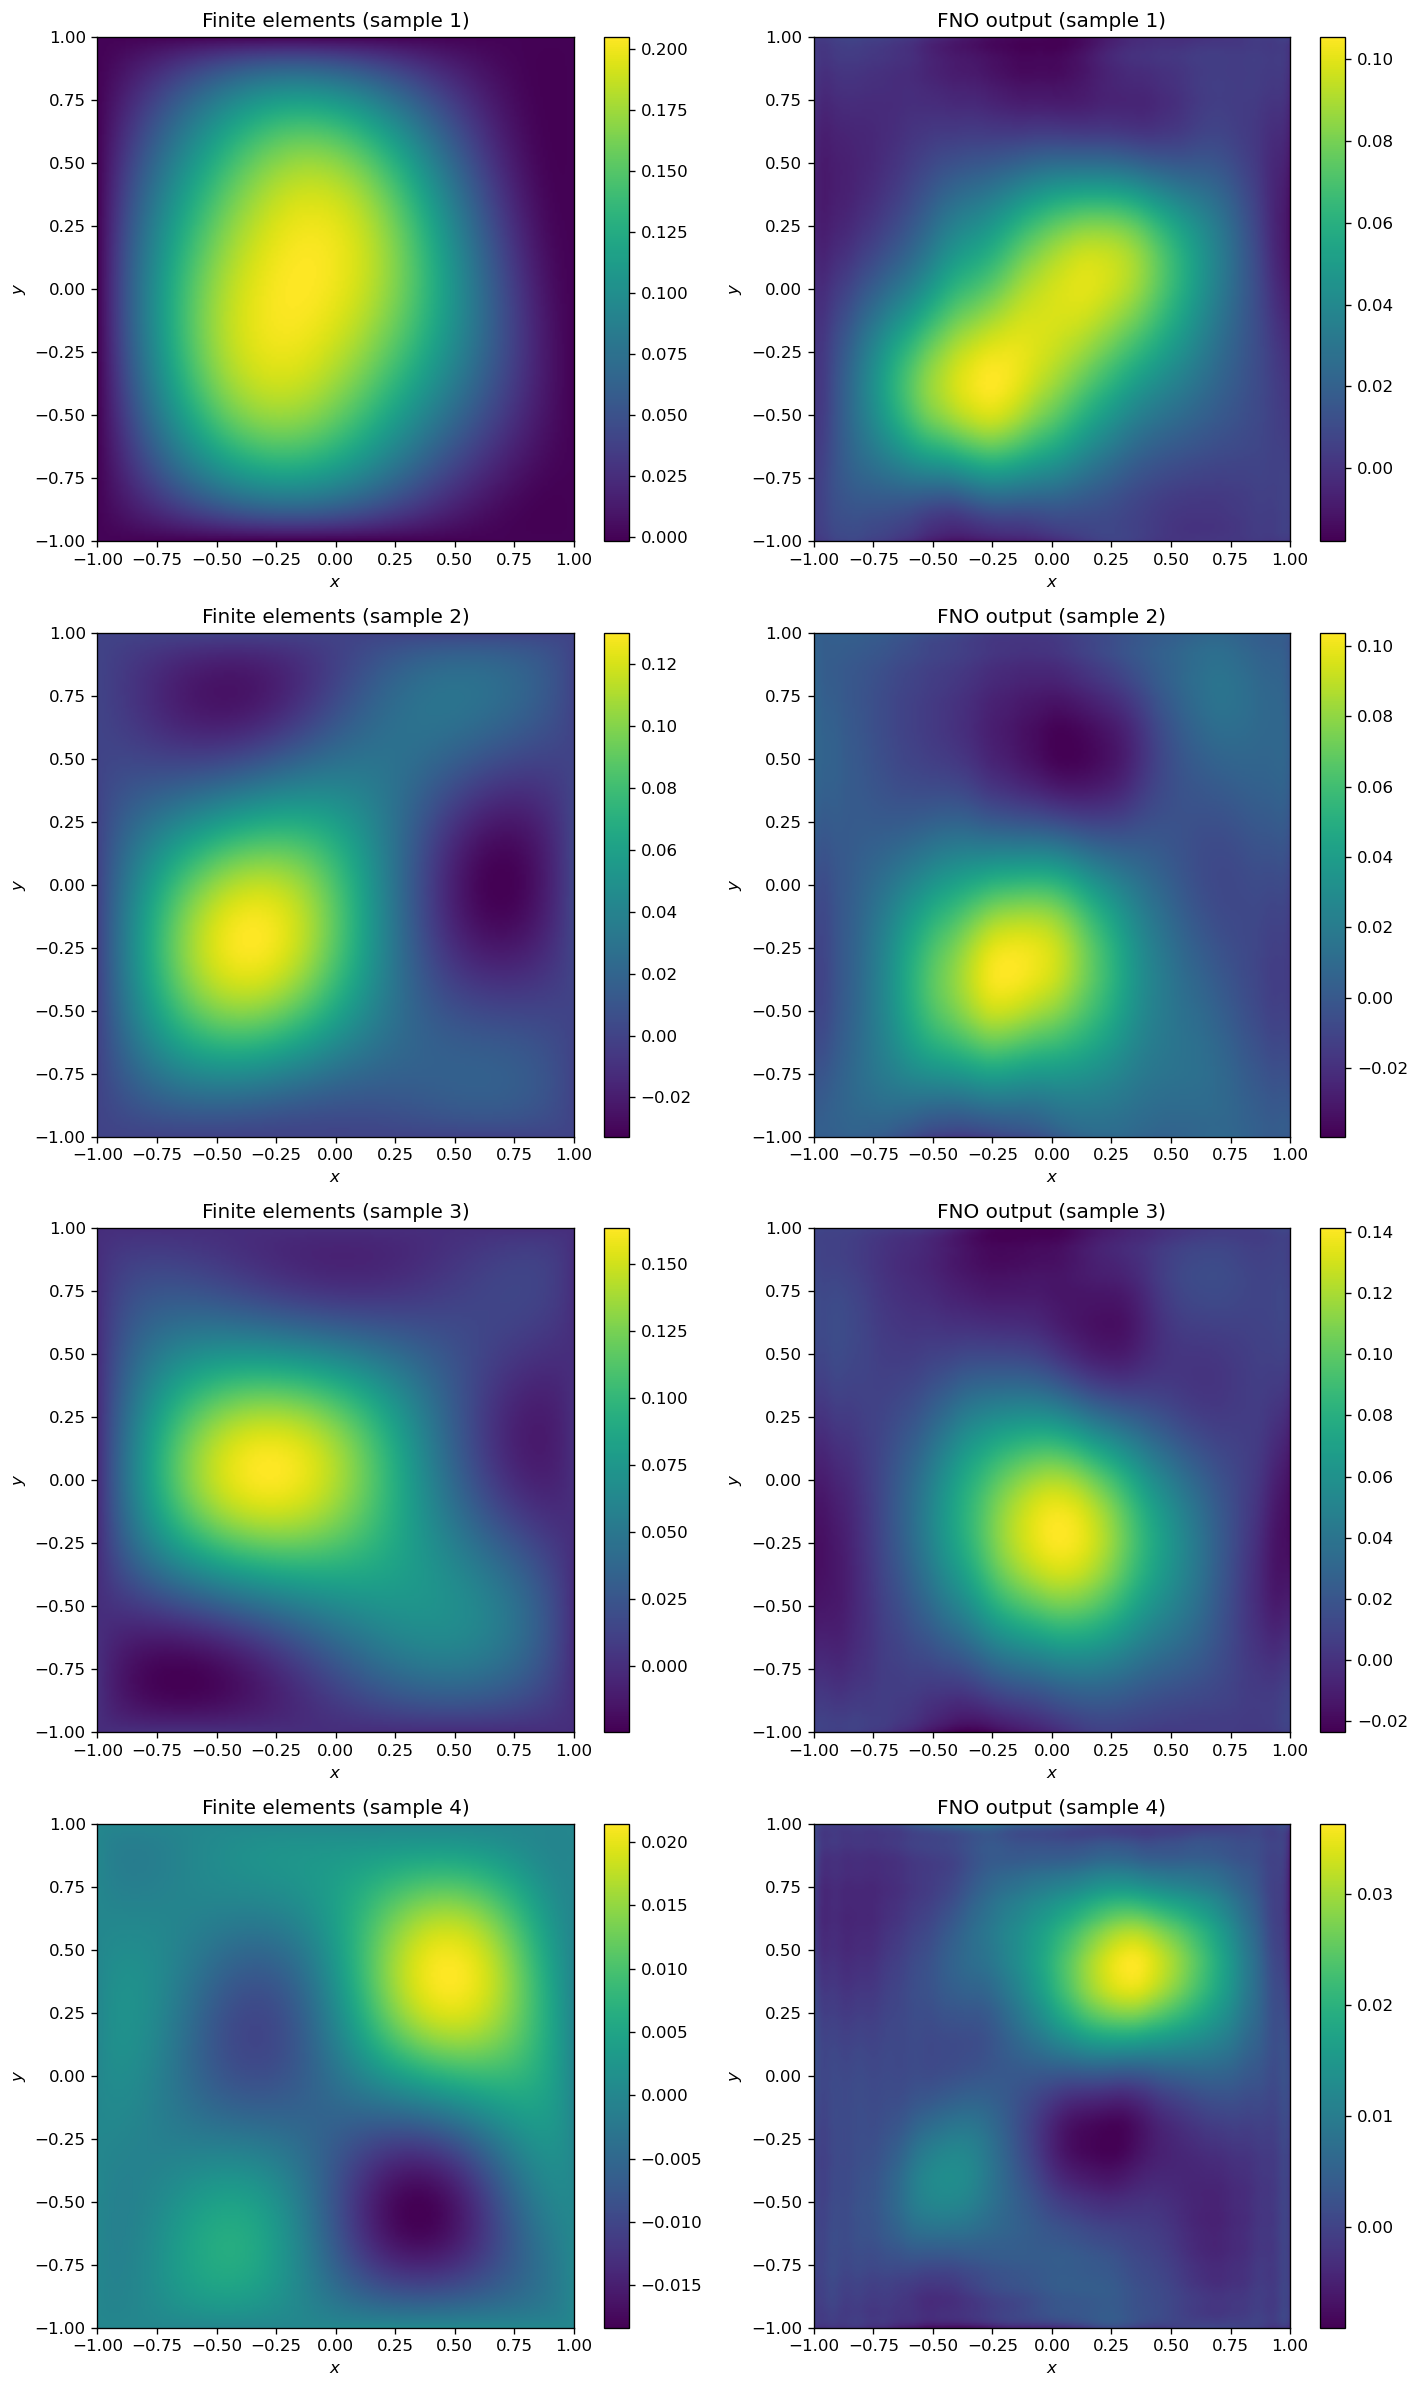

In [5]:
# now test visually on 4 randomly generated functions

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

X, Y = np.meshgrid(x, y, indexing="ij")
diri = lambda x, y: 0

N_test = 4
fig, axes = plt.subplots(N_test, 2, figsize=(12, 5 * N_test), dpi=120)

for i in range(N_test):
    func = generate_source_function()

    res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
    result_fno = fno_trial.map_function_to_output_at_points(func, X, Y)

    im0 = axes[i, 0].imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 0].set_title(f'Finite elements (sample {i+1})')
    axes[i, 0].set_xlabel('$x$')
    axes[i, 0].set_ylabel('$y$')
    fig.colorbar(im0, ax=axes[i, 0])

    im1 = axes[i, 1].imshow(result_fno, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 1].set_title(f'FNO output (sample {i+1})')
    axes[i, 1].set_xlabel('$x$')
    axes[i, 1].set_ylabel('$y$')
    fig.colorbar(im1, ax=axes[i, 1])

plt.tight_layout()
plt.show()

**Comments**

- results for a test function are usually (not always) vaguely reminiscent of the expected result, but still quite far away 
- quite distinctive overtraining issue
- spectral oscillations quite evident at 100 epochs, much less at 25 epochs. sign of overtraining
- so far only 100 iterations (otherwise just overtrainig). need to fix hyperparameters to go beyond

# Trying with FNO from neuralop.models (NeuralOperator library)

note here that the data structure is (f,x,y) - in my own model I use (x,y,f)

https://github.com/neuraloperator/neuraloperator

In [8]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop import LpLoss, H1Loss
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # need this for CPU fallback if mps support for somme fft-related operations is incomplete
from neuralop.data.datasets.tensor_dataset import TensorDataset

#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # "mps" gives issues in backward. need to use "cpu"
device = torch.device("cpu")

# first load the training an test data
train_data = torch.load("data/poisson_train_48.pt")
test_data = torch.load("data/poisson_test_48.pt")


# define the train and test dataset with TensorDataset from the neuralop library
# neuralop expects each batch to be a dictionary with keys 'x', 'y'
train_dataset = TensorDataset(x=train_data['x'], y=train_data['y'])
test_dataset  = TensorDataset(x=test_data['x'], y=test_data['y'])

# define the train and test loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

# define the model
model = FNO(n_modes=(16, 16), hidden_channels=24, in_channels=3, out_channels=1).to(device)

"""
# check if forward pass produced nans 
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader)) # iter creates an iterator over train_loader, next pull its first batch
    out = model(sample['x'].to(device))
    print(torch.isnan(out).any(), out.min(), out.max())"""

# define the optimizer and the scheduler
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) # CosineAnnealing: smooth decay of the learning rate

# define the losses
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

# use MSE loss as safe loss (h1loss may have numerical instabilities which may end up in nans)
# need to package the loss this way because neuralop's trainer calls the loss as training_loss(out, **sample), where sample is the full batch dict ({'x': ..., 'y': ...})
class SafeMSELoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = torch.nn.MSELoss()

    def __call__(self, y_pred, y, **kwargs):
        return self.mse(y_pred, y)

train_loss = SafeMSELoss()
eval_losses = {'l2': l2loss, 'h1': h1loss} 

# define the trainer
trainer = Trainer(
    model=model,
    n_epochs=30,
    device=device,
    wandb_log=False,
    eval_interval=3,
    use_distributed=False,
    verbose=True
)

#torch.autograd.set_detect_anomaly(True) # troubleshooting (used when I was getting nans)

# now do the training
history = trainer.train(
    train_loader=train_loader,
    test_loaders={'test': test_loader},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    eval_losses=eval_losses
)

Training on 800 samples
Testing on [200] samples         on resolutions ['test'].


/opt/homebrew/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)


Raw outputs of shape torch.Size([16, 1, 48, 48])
[0] time=15.11, avg_loss=0.0002, train_err=0.0035


/Users/filippo/neuraloperator/neuralop/training/trainer.py:581: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)
/Users/filippo/neuraloperator/neuralop/training/trainer.py:581: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)


Eval: test_l2=0.9787, test_h1=1.0751
[3] time=14.92, avg_loss=0.0001, train_err=0.0024
Eval: test_l2=1.0090, test_h1=1.0405
[6] time=14.82, avg_loss=0.0001, train_err=0.0018
Eval: test_l2=0.9349, test_h1=0.9968
[9] time=15.27, avg_loss=0.0001, train_err=0.0016
Eval: test_l2=0.9163, test_h1=0.9416
[12] time=14.85, avg_loss=0.0001, train_err=0.0016
Eval: test_l2=0.8642, test_h1=0.8914
[15] time=15.02, avg_loss=0.0001, train_err=0.0015
Eval: test_l2=0.8495, test_h1=0.8582
[18] time=15.03, avg_loss=0.0001, train_err=0.0015
Eval: test_l2=0.8680, test_h1=0.8678
[21] time=14.92, avg_loss=0.0001, train_err=0.0015
Eval: test_l2=0.8488, test_h1=0.8512
[24] time=15.18, avg_loss=0.0001, train_err=0.0015
Eval: test_l2=0.8522, test_h1=0.8504
[27] time=15.07, avg_loss=0.0001, train_err=0.0014
Eval: test_l2=0.8479, test_h1=0.8479


dict_keys(['train_err', 'avg_loss', 'avg_lasso_loss', 'epoch_train_time'])
15.125248875003308
<class 'float'> 8.949919916631188e-05


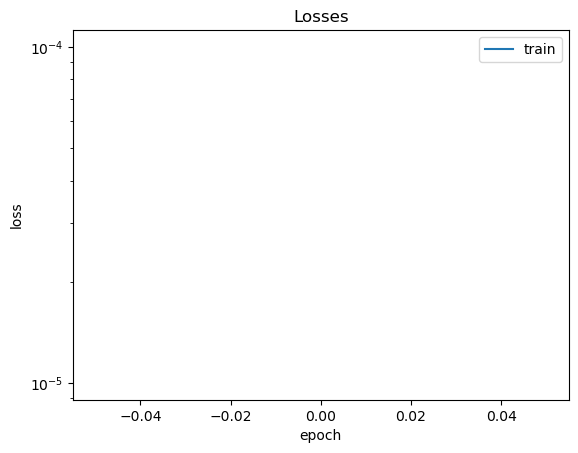

In [9]:
# TO DO: need to save the losses myself because trainer only saves the last value

print(history.keys())  # check exact key names first: they vary by version


print(history['epoch_train_time'])
print(type(history['avg_loss']), history['avg_loss'])

# now plot the errors as a function of the epoch
plt.figure()
plt.title('Losses')
plt.plot(history['avg_loss'], label='train')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.yscale('log')
plt.legend()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


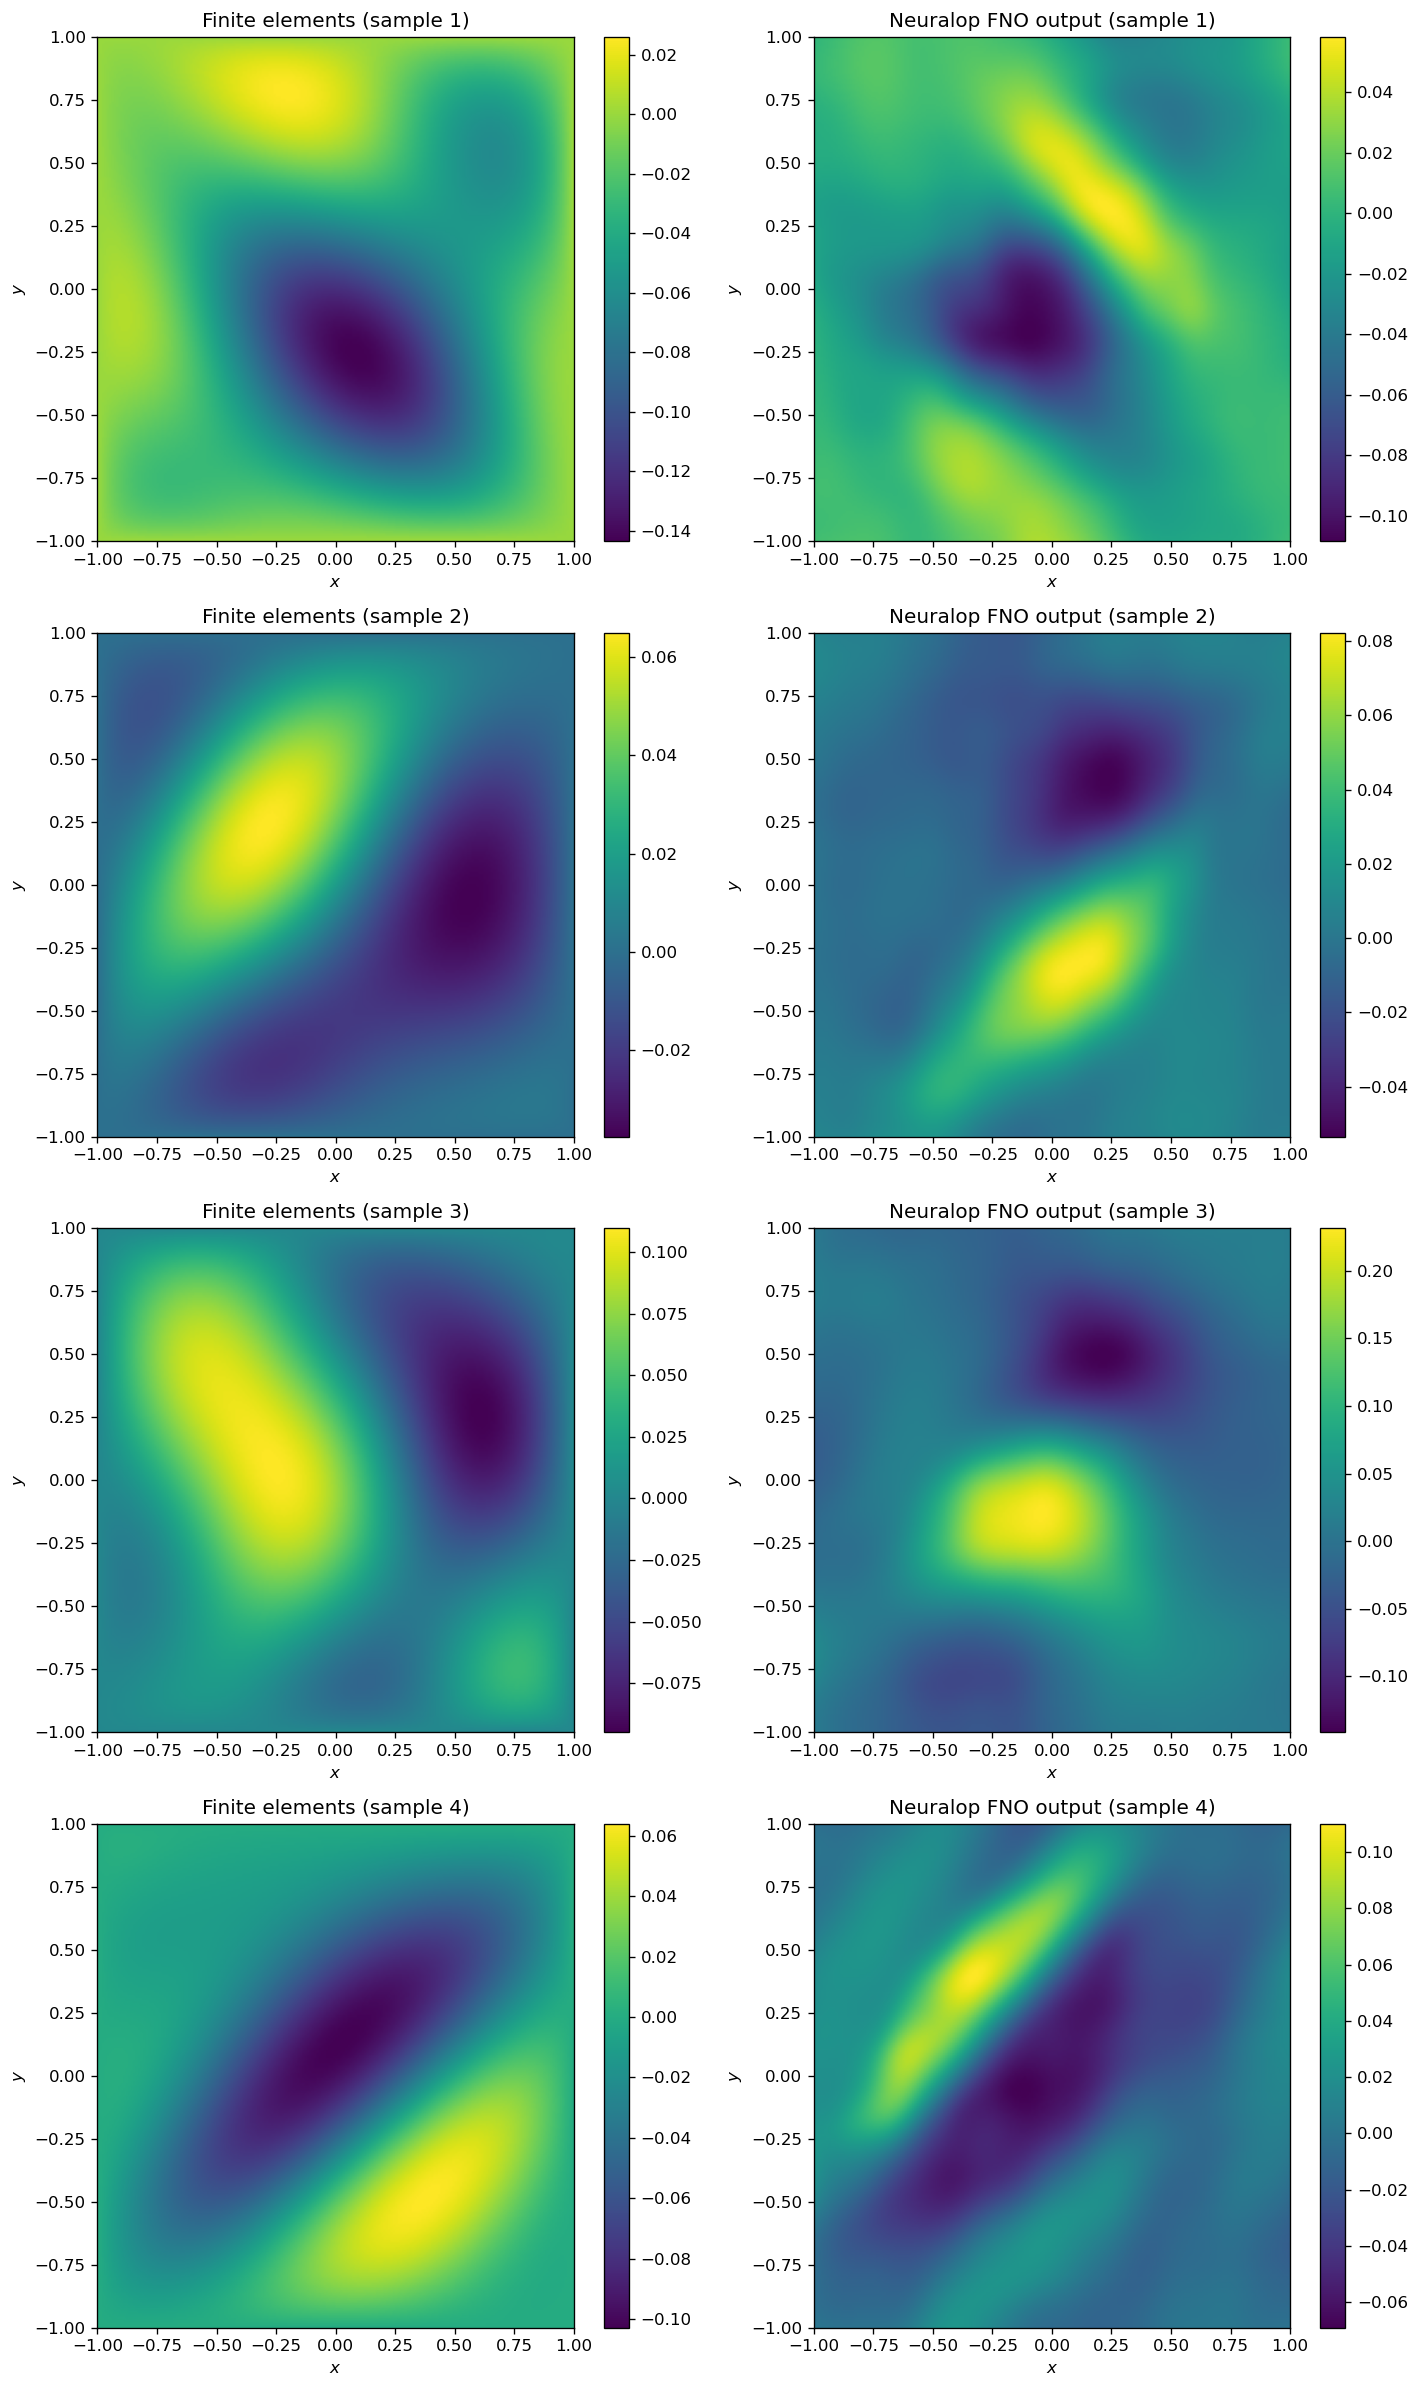

In [11]:
# now test visually on 4 randomly generated functions

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

X, Y = np.meshgrid(x, y, indexing="ij")
diri = lambda x, y: 0

model.eval()

N_test = 4
fig, axes = plt.subplots(N_test, 2, figsize=(12, 5 * N_test), dpi=120)

for i in range(N_test):
    func = generate_source_function()

    res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

    # build (1, 3, H, W) input: channels = f, x, y -- matches training data order
    F = func(X, Y)
    model_input = np.stack([F, X, Y], axis=0)  # (3, H, W)
    model_input = torch.from_numpy(model_input).float().unsqueeze(0).to(device)  # (1, 3, H, W)

    with torch.no_grad():
        result_fno = model(model_input).squeeze(0).squeeze(0).cpu().numpy()  # double squeeze: from (1, 1, H, W) to (H, W)

    im0 = axes[i, 0].imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 0].set_title(f'Finite elements (sample {i+1})')
    axes[i, 0].set_xlabel('$x$')
    axes[i, 0].set_ylabel('$y$')
    fig.colorbar(im0, ax=axes[i, 0])

    im1 = axes[i, 1].imshow(result_fno, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 1].set_title(f'Neuralop FNO output (sample {i+1})')
    axes[i, 1].set_xlabel('$x$')
    axes[i, 1].set_ylabel('$y$')
    fig.colorbar(im1, ax=axes[i, 1])

plt.tight_layout()
plt.show()

**Comments**

Using the `neuraloperator` library, the steps are very slow - and they often yield nan losses (I still have to understand why - maybe need normalizing)?
Work still in progress... for now not working



# TO DO

- check number of Fourier layers in neuralop model
- use same scheduler on both models: 

        self.optimizer = AdamW(self.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=30) # CosineAnnealing: smooth decay of the learning rate

    gives nans on my model, for some reason that I still need to understand
- compare my model and the one from the neuralop library side-by-side
- plot loss and eval losses (h1, l2) on neuralop model as a function of epoch
- optimize hyperparameters for best training performance (avoiding overfitting)